<a href="https://colab.research.google.com/github/pyafv/assets/blob/main/jupyter/active_dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install **pyafv** in Google Colab

In [ ]:
!pip install pyafv

### Relaxation to mechanical equilibrium

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import pyafv as afv

In [3]:
np.random.seed(42)

N = 100         # number of cells
radius = 1.0    # maximal radius
mu = 1.0        # mobility
dt = 0.01       # time step

# Parameter set
phys = afv.PhysicalParams(
    r=radius,
    A0=np.pi*(radius**2),
    P0=4.8*radius,
    KA=1.0,
    KP=1.0,
    Lambda=0.2
)

In [4]:
# Do not set delta unless you know what you are doing.
# We set it to zero here for comparison with the our primitive results.
phys = phys.replace(delta=0.0)

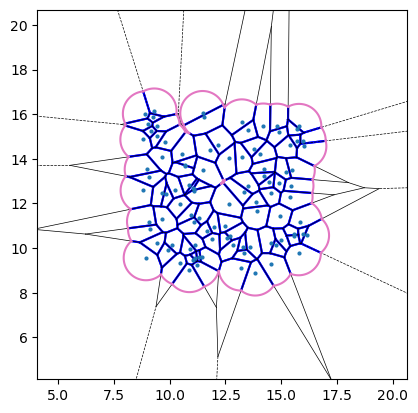

In [5]:
# Initial positions
pts = np.random.rand(N, 2)*0.3 + 0.35  # shape (N,2)
pts *= 25.

# Initialize simulator
sim = afv.FiniteVoronoiSimulator(pts, phys)

# Plot initial configuration
fig, ax = plt.subplots()
sim.plot_2d(ax=ax)
plt.show()

Relaxation:   0%|          | 0/1000 [00:00<?, ?it/s]

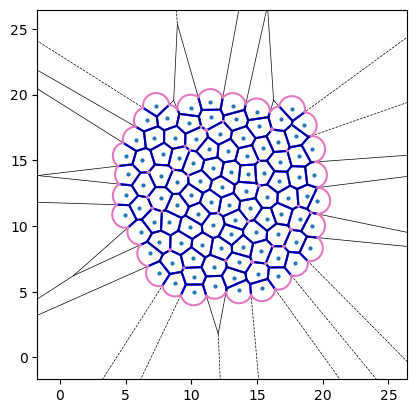

In [6]:
# Relaxation to mechanical equilibrium
for _ in tqdm(range(1000), desc="Relaxation"):
    diag = sim.build()
    forces = diag["forces"]
    pts += mu * forces * dt
    sim.update_positions(pts)

# Plot relaxed configuration
fig, ax = plt.subplots()
sim.plot_2d(ax=ax)
plt.show()

### Active finite Voronoi (AFV) dynamics

This is basically just as simple to run a AFV model as it is to simulate a bunch of random walks:

In [7]:
v0 = 2.4        # self-propulsion speed
Dr = 0.3        # rotational diffusion constant

theta = 2. * np.pi * np.random.rand(N) - np.pi

In [8]:
# Active dynamics
for _ in tqdm(range(1000), desc="Active dynamics"):
    diag = sim.build()
    forces = diag["forces"]

    active_velocity = v0 * np.column_stack((np.cos(theta), np.sin(theta)))

    pts += (mu * forces + active_velocity) * dt

    # Gaussian white noise
    theta += np.sqrt(2 * Dr * dt) * np.random.randn(N)

    sim.update_positions(pts)

Active dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

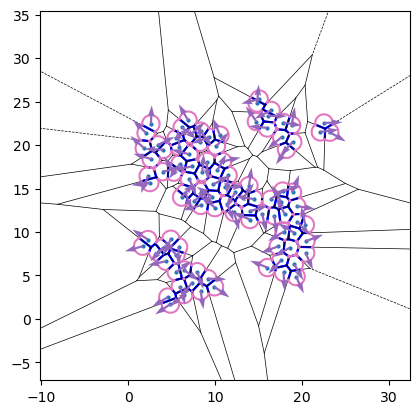

In [9]:
fig, ax = plt.subplots()
sim.plot_2d(ax=ax)
# Plot cell orientations
ax.quiver(pts[:, 0], pts[:, 1], np.cos(theta), np.sin(theta), color='C4', scale=20, zorder=3)
plt.show()

### Show connectivity between cells

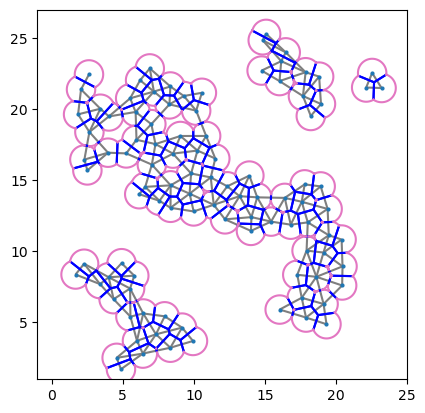

In [10]:
from matplotlib.collections import LineCollection

diag = sim.build()
connect = diag["connections"]

# Plot initial configuration
fig, ax = plt.subplots()
sim.plot_2d(ax=ax, show_voronoi=False)

# Plot the connections between cells
num_connections = connect.shape[0]
if num_connections > 0:
    i_masked = connect[:, 0]
    j_masked = connect[:, 1]
    # Build list of segments (line endpoints) for visualization, shape: (num_pairs, 2, 2)
    segments = np.stack([pts[i_masked], pts[j_masked]], axis=1)
    # Create LineCollection
    lc = LineCollection(segments, colors="C7", linewidths=1.5, zorder=0)
    ax.add_collection(lc)

ax.set_xlim(-1, 25)
ax.set_ylim(1, 27)
plt.show()